<a href="https://colab.research.google.com/github/Annette-1/Ecuaciones_Diferenciales_Parciales/blob/main/M%C3%A9todo_para_determinar_cuando_detenerse_al_generar_nuevos_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:magenta;">**Método para determinar cuando detenerse al generar nuevos datos**</span>

<span style="color:teal;">**Nombre:** </span> Jerónimo López Annette Michelle

<span style="color:teal;"> **Objetivo:**</span> Estimar numéricamente la integral mediante el método de Monte Carlo, utilizando variables aleatorias uniformes y un criterio de parada basado en el error estándar de la estimación, para obtener una aproximación con una precisión previamente especificada.

### **Resolvemos la integral primero de manera analítica:**

$$
I=\int_0^1 e^{x^2},dx
$$

**no puede expresarse mediante funciones elementales** (polinomios, exponenciales, logaritmos, funciones trigonométricas, etc.). Por ello, su valor exacto se escribe usando la función especial **erfi** (error imaginaria).

---

1. Usando un cambio de variable

La función error imaginaria se define como

$$
\operatorname{erfi}(x)=
\frac{2}{\sqrt{\pi}}
\int_0^x e^{t^2},dt.
$$

Despejando la integral,

$$
\int_0^x e^{t^2},dt= \frac{\sqrt{\pi}}{2}\operatorname{erfi}(x).
$$

Entonces,

$$
I=\left[\frac{\sqrt{\pi}}{2}\operatorname{erfi}(x)\right]_0^1.
$$

Como
$$[
\operatorname{erfi}(0)=0,
$$

obtenemos

$$
I=\frac{\sqrt{\pi}}{2}\operatorname{erfi}(1).
$$

2. Valor numérico

Usando

$$
\operatorname{erfi}(1)\approx 1.6504257588,
$$

resulta

$$
I=\frac{\sqrt{\pi}}{2}(1.6504257588)
$$

$$
I \approx
1.4626517459.
$$

3. Verificación mediante serie de Taylor

Sabemos que

$$
e^{x^2}=\sum_{n=0}^{\infty}\frac{x^{2n}}{n!}.
$$

Integrando término a término en ([0,1]),

$$
I=\int_0^1\sum_{n=0}^{\infty}\frac{x^{2n}}{n!},dx=\sum_{n=0}^{\infty}\frac{1}{n!}\int_0^1 x^{2n},dx.
$$

Como

$$
\int_0^1 x^{2n},dx=\frac{1}{2n+1},
$$

obtenemos

$$
I=\sum_{n=0}^{\infty}\frac{1}{(2n+1)n!}.
$$

Es decir,

$$
I=1+\frac13+\frac1{10}+\frac1{42}+\frac1{216}+\cdots
$$

y la suma converge a

$$
I\approx1.4626517459.
$$

**Resultado analítico**

$$
\boxed{
\int_0^1 e^{x^2},dx=\frac{\sqrt{\pi}}{2},\operatorname{erfi}(1)}
$$

y numéricamente

$$
\boxed{
\int_0^1 e^{x^2},dx \approx1.4626517459.}
$$


<span style="color:magenta;">*Seudocódigo principio de este Método*</span>

1. Elegir un valor aceptable $d$ para la desviación estándar.
2. Generar al menos $30$ datos.
3. Continuar generando hasta $k$ valores, tales que $ \frac{S}{\sqrt{k}}< d$, donde $S$ es la desviación estándar muestral de los $k$ valores.
4. La estimación de $θ$ esá dada por $\bar{X}= ∑_{i=1}^k \frac{x_i}{k}$

 <span style="color:purple;">**Actividad**</span>

 Estime
 $$
 ∫_0^1 e ^{x^2}dx\quad,\quad por \quad MC
 $$

 Genere al menos $100$ valores y deténganse cuando la desviación estándar de su estimador son menor que $0.01 \quad y \quad 0.001$

<span style="color:purple;">**Fórmulas recursivas**</span>

con $\bar{X}=0$ ; $S_1^2=0$

$\bar{X}_{j+1}=\bar{X}_j+\frac{\bar{X}_{j+1}-\bar{X}_{j}}{j+1}$

$$
S_{j+1}^2=  \left( 1-\frac{1}{j} \right) S_j^2+ (j+1) \left( \bar{X}_{j+1} - \bar{X}_{j} \right)^2
$$

Generamos el algoritmo o bien el seudocódigo:

1. Inicializar $k=0$, lista de valores valores = [] (es decir lista vacía).
2. Mientras $k < 30$ o $\frac{S_k}{\sqrt{k}} \ge d$:

   · Generar $U \sim U(0,1)$ (Distribución Unifrome).

   · Calcular $X = e^{U^2}$.

   · Agregar $X$ a la lista.

   · $k \gets k+1$.
3. Estimar $\theta = \bar{X}_k$.

In [213]:
#Importamos las librerías
import numpy as np
import math
#Esta librería proporciona acceso a un amplio conjunto de funciones matemáticas
import matplotlib.pyplot as plt

Definimos una distribución uniforme par crear los datos

In [214]:
def generar_observacion():
    """
    Genera una observación X = exp(U²),
    donde U ~ U(0,1).
    """
    u = np.random.uniform(0, 1)
    return np.exp(u**2)

In [215]:
generar_observacion()# hacemos una prueba para observar que nos devuelva un valor

np.float64(1.6586690021106445)

Usando la librería Math calculamos la media y la varianza para:

Actualizar media y varianza recursivamente

Se implementan las fórmulas recursivas dadas en el enunciado.

In [216]:
def actualizar_estadisticas(j, x, media, s2):
    """
    Actualiza media y varianza muestral recursivamente.
    Parámetros
    ----------
    j :Número actual de observaciones.
    x :Nueva observación .
    media :Media anterior.
    s2 :  Varianza muestral anterior.
    Retorna
    -------
    media_nueva, s2_nueva
    """

    if j == 0:
        return x, 0.0

    media_nueva = media + (x - media)/(j + 1)

    s2_nueva = ((j - 1)/j)*s2 + (j + 1)*(media_nueva - media)**2

    return media_nueva, s2_nueva

Usamos la Simulación Monte Carlo con criterio de parada

In [217]:
def monte_carlo_integral(d, minimo=100):
    """
    Estima la integral usando el método de  Monte Carlo.
    Se generan al menos 'minimo' observaciones
    y se detiene cuando:
        S/sqrt(k) < d
    Parámetros
    ----------
    d : Error estándar deseado.
    minimo : Número mínimo de observaciones.
    Retorna
    -------
    theta_hat : estimación
    k : número de simulaciones
    error_estandar : error estándar final
    """
    historial = []# creamos una lista vacia
    errores = [] #erros servira para ver esto en la grafica
    iteraciones = []
    k = 0
    media = 0.0
    s2 = 0.0

    while True:

        x = generar_observacion()

        media, s2 = actualizar_estadisticas(
            k, x, media, s2
        )

        k += 1

        historial.append(media)

        if k > 1:
            S = np.sqrt(s2)
            error_estandar = S / np.sqrt(k)
        else:
            error_estandar = np.inf

        errores.append(error_estandar)
        iteraciones.append(k)

        if k >= minimo and error_estandar < d:
            break

    return media, k, error_estandar, historial, errores, iteraciones

Ejecutamos el programa creanso una funcion para ejecutar todas las funciones:

In [218]:
def main():
    print("ESTIMACIÓN DE ∫ exp(x²) dx EN [0,1]")
    print("="*60)

    tolerancias = [0.01, 0.001]

    for d in tolerancias:

        estimacion, k, error, historial, errores, iteraciones = monte_carlo_integral(d)

        print(f"\nTolerancia d = {d}")
        print(f"Número de simulaciones = {k}")
        print(f"Estimación = {estimacion:.8f}")
        print(f"Error estándar = {error:.8f}")

if __name__ == "__main__": # Este comando nos sirve para ejecutar todas las funciones usadas anteriormente
    main()                 # y se ejecute todo el código

ESTIMACIÓN DE ∫ exp(x²) dx EN [0,1]

Tolerancia d = 0.01
Número de simulaciones = 2244
Estimación = 1.45639779
Error estándar = 0.00999892

Tolerancia d = 0.001
Número de simulaciones = 223889
Estimación = 1.46131163
Error estándar = 0.00100000


Graficamos para ellos nos apoyamos de lo siguiente:

In [219]:
d_to_plot = 0.01

estimacion, k, error, historial, errores, iteraciones = \
    monte_carlo_integral(d_to_plot)

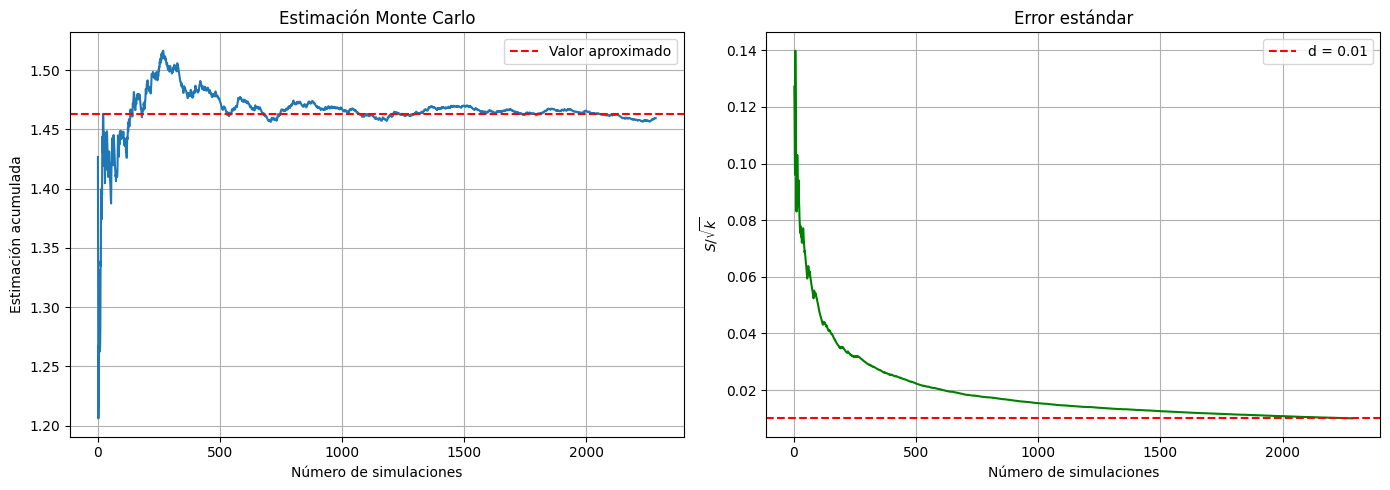

In [220]:
valor_real = 1.4626517459

fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Convergencia de la estimación

ax[0].plot(iteraciones, historial)

ax[0].axhline(
    valor_real,
    color='red',
    linestyle='--',
    label='Valor aproximado'
)

ax[0].set_title('Estimación Monte Carlo')
ax[0].set_xlabel('Número de simulaciones')
ax[0].set_ylabel('Estimación acumulada')
ax[0].grid(True)
ax[0].legend()

# Error estándar

ax[1].plot(
    iteraciones,
    errores,
    color='green'
)

ax[1].axhline(
    d_to_plot,
    color='red',
    linestyle='--',
    label=f'd = {d_to_plot}'
)

ax[1].set_title('Error estándar')
ax[1].set_xlabel('Número de simulaciones')
ax[1].set_ylabel(r'$S/\sqrt{k}$')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

¿Qué observamos en las gráficas?

* Al inicio la estimación fluctúa bastante debido a la aleatoriedad.
* Conforme aumenta el número de simulaciones, las fluctuaciones disminuyen.
* La curva se estabiliza cerca de

$$
\int_0^1 e^{x^2},dx \approx 1.46265.
$$

* Esto muestra la **convergencia del estimador Monte Carlo** al valor de la integral.

Esta única gráfica suele ser suficiente para un reporte o práctica de simulación.


<span style="color:green;">**Cálculo del Intervalo de Confianza del 95%**</span>

tendremos dos Intervalos para $d = 0.01$ y $d = 0.001$

In [221]:
Z_critico = 1.96 #valor de tablas de la normal estanadar

# Simulación con d = 0.01
estimacion1, n1, error1, historial1, errores1, iteraciones1 = monte_carlo_integral(0.01)

# Simulación con d = 0.001
estimacion2, n2, error2, historial2, errores2, iteraciones2 = monte_carlo_integral(0.001)

# Intervalo de confianza para d = 0.01
ci_lower_01 = estimacion1 - Z_critico * error1
ci_upper_01 = estimacion1 + Z_critico * error1

# Intervalo de confianza para d = 0.001
ci_lower_001 = estimacion2 - Z_critico * error2
ci_upper_001 = estimacion2 + Z_critico * error2
# Resultados
print("INTERVALOS DE CONFIANZA DEL 95%")
print("="*60)

print(f"\nd = 0.01")
print(f"Estimación = {estimacion1:.8f}")
print(f"IC 95% = [{ci_lower_01:.8f}, {ci_upper_01:.8f}]")

print(f"\nd = 0.001")
print(f"Estimación = {estimacion2:.8f}")
print(f"IC 95% = [{ci_lower_001:.8f}, {ci_upper_001:.8f}]")

INTERVALOS DE CONFIANZA DEL 95%

d = 0.01
Estimación = 1.45591035
IC 95% = [1.43631286, 1.47550783]

d = 0.001
Estimación = 1.46439847
IC 95% = [1.46243848, 1.46635847]


Con esto podemos concluir que:

Si se repitiera el procedimiento muchas veces, aproximadamente el 95% de los intervalos construidos contendrían el valor real de la integral.

* Para $d=0.01$, el intervalo será más ancho porque se permite un error estándar mayor.
* Para $d=0.001$, el intervalo será más estrecho, lo que indica una estimación más precisa, aunque requiere muchas más simulaciones.
* Si el valor teórico $1.4626517459$ queda dentro de ambos intervalos, la simulación es consistente con el valor real de la integral.



### <span style="color:teal;">**Comparación valor exacto vs Sumlación**</span>

La integral

$$
\int_0^1 e^{x^2},dx
$$

no tiene primitiva elemental, pero numéricamente vale aproximadamente

$$
\int_0^1 e^{x^2},dx \approx 1.4626517459.
$$
Por lo tanto, las estimaciones Monte Carlo deberían acercarse a ese valor cuando aumenta el número de simulaciones.


 ## <span style="color:purple;">**Conclusión:**</span>

 El método de Monte Carlo permitió estimar la integral
$$
\int_0^1 e^{x^2},dx
$$

a partir de observaciones aleatorias de la variable $X=e^{U^2}$, donde $U\sim U(0,1)$. Se observó que la estimación se aproxima progresivamente al valor real de la integral conforme aumenta el número de simulaciones, verificando la convergencia establecida por la Ley de los Grandes Números.

Además, el criterio de parada basado en el error estándar
$$
\frac{S}{\sqrt{k}}<d
$$

permitió controlar la precisión de la estimación de manera automática. Cuando se utilizó una tolerancia más estricta $(d=0.001)$, fue necesario generar un número considerablemente mayor de observaciones que para $d=0.01$, lo que evidencia la relación entre precisión y costo computacional.

En conclusión, el método Monte Carlo constituye una herramienta eficaz para aproximar integrales complejas, especialmente cuando no existe una solución analítica sencilla, aunque una mayor precisión requiere incrementar el número de simulaciones realizadas.


# <span style="color:magenta;">**Técnica de Reducción de Varianza** </span>

<span style="color:teal;">**Nombre:** </span> Jerónimo López Annette Michelle

<span style="color:teal;"> **Objetivo:**</span>Reducir la varianza del estimador Monte Carlo sin aumentar el número de simulaciones, obteniendo estimaciones más precisas con el mismo esfuerzo computacional.

<span style="color:purple;">**De la Actividad**</span> anterior usaremos el metodo de reducción de varianza para varibles antitéticas y veamos la eficiencia de este para reducir el número de simulaciones

 Estime
 $$
 ∫_0^1 e ^{x^2}dx
 $$

Las técnicas de reducción de varianza reducen el costo computacional: **mejoran la precisión sin aumentar** el número de simulaciones.

Partimos de:

$$
\text{Var} \left( \frac{x_1 + x_2}{2} \right) = \frac{1}{4} \left[ \text{Var}(x_1) + \text{Var}(x_2) + 2\,\text{Cov}(x_1, x_2) \right]
$$

Donde:

$$
\text{Cov}(x_1, x_2) = \text{E}[x_1 x_2] - \text{E}[x_1] \text{E}[x_2]
$$

La fórmula anterior muestra que podemos reducir la varianza si $\text{Cov}(x_1, x_2)$ es negativa.  
Las **variables antitéticas** son aquellas que tienen covarianza negativa.

Tenemos que el valor exacto de la integral

$$
\int_0^1 e^{x^2},dx
$$
 vale aproximadamente

$$
\int_0^1 e^{x^2},dx \approx 1.4626517459.
$$

In [222]:
#Importamos las librerias necesarias
import numpy as np
import matplotlib.pyplot as plt
import random as r

Definimos la función

In [223]:
# Función a integrar
def f(x):
    return np.exp(x**2)
valor_real = 1.4626517459

In [224]:
f(1) #evaluamos para ver si funciona XD

np.float64(2.718281828459045)

Ahora pocedemos a aplicar el **Método de Monte Carlo** para un primer estimador con parámetros:

    """
    Estimador Monte Carlo.

    Parametros de la función
    ----------
    f : función
    N : Número de simulaciones
    Retorna
    -------
        Estimación de la integral
    """

Se comportará como:

$$
θ_1= \frac{1}{N} ∑_{i=0}^N f(U_i) \quad ,\quad U_i ∼U(0,1)
$$

In [225]:
def mc_estandar(f, N):#para el primer estimador theta_1
    suma = 0
    for i in range(N):
        u = r.random()
        suma += f(u)
    return suma/N

Aplicamos el método de Monte carlo para $θ_2$ o bien para las varibles **antitéticas** esta se comportará como:

$$
θ_2= \frac{1}{N} ∑_{i=0}^N f(1-U_i) \quad ,\quad U_i ∼U(0,1)
$$

O bien podemos expresarlo como el promedio de estos dos estimadores

$$
\hat\theta_{A}=\frac1N\sum_{i=1}^{N}\frac{e^{U_i^2}+e^{(1-U_i)^2}}{2}.
$$


In [226]:
def mc_antitetico(f, N):
    suma = 0
    for i in range(N):
        u = r.random()
        suma += (f(u) + f(1-u))/2
    return suma/N

Haremos varias repeticiones para **Comparar las varianzas**

In [227]:
N = 1000          # simulaciones por experimento
R = 100           # repeticiones independientes

resultados_mc = [] #Creamos las listas vacias
resultados_ant = []

for i in range(R):

    resultados_mc.append(
        mc_estandar(f, N)
    )

    resultados_ant.append(
        mc_antitetico(f, N)
    )
resultados_mc = np.array(resultados_mc)
resultados_ant = np.array(resultados_ant)

Calculamos las estadistícas de la media y la varianza

In [228]:
media_mc = np.mean(resultados_mc)
var_mc = np.var(resultados_mc, ddof=1)

media_ant = np.mean(resultados_ant)
var_ant = np.var(resultados_ant, ddof=1)

error_mc = np.std(resultados_mc, ddof=1)/np.sqrt(R)
error_ant = np.std(resultados_ant, ddof=1)/np.sqrt(R)

Calculamos el intervalo de Confianza igual para el $95\%$

In [229]:
z = 1.96 # valor de tablas
ic_mc_inf = media_mc - z*error_mc
ic_mc_sup = media_mc + z*error_mc

ic_ant_inf = media_ant - z*error_ant
ic_ant_sup = media_ant + z*error_ant

Ahora imprimiremos todo lo anterior en una sola celda para visualizar los resultados:

In [230]:
print("="*60)
print("MONTE CARLO TRADICIONAL")
print("="*60)

print(f"Media     = {media_mc:.8f}")
print(f"Varianza  = {var_mc:.10f}")
print(f"Error Est = {error_mc:.8f}")
print(f"IC 95%    = [{ic_mc_inf:.8f}, {ic_mc_sup:.8f}]")

print("\n")

print("="*60)
print("MONTE CARLO ANTITÉTICO")
print("="*60)

print(f"Media     = {media_ant:.8f}")
print(f"Varianza  = {var_ant:.10f}")
print(f"Error Est = {error_ant:.8f}")
print(f"IC 95%    = [{ic_ant_inf:.8f}, {ic_ant_sup:.8f}]")

print("\n")

print(f"Valor exacto = {valor_real:.8f}")



MONTE CARLO TRADICIONAL
Media     = 1.46189111
Varianza  = 0.0001741826
Error Est = 0.00131978
IC 95%    = [1.45930433, 1.46447788]


MONTE CARLO ANTITÉTICO
Media     = 1.46273499
Varianza  = 0.0000266295
Error Est = 0.00051604
IC 95%    = [1.46172356, 1.46374643]


Valor exacto = 1.46265175


Comparemos como se redujo la varianza

In [233]:
reduccion = (1 - var_ant/var_mc)*100
print(f"Reducción porcentual de varianza = {reduccion:.2f}%")
print("Varianza MC =", var_mc)
print("Varianza Antitética =", var_ant)

print("Factor de reducción =",
      var_mc/var_ant)

Reducción porcentual de varianza = 84.71%
Varianza MC = 0.00017418263803755513
Varianza Antitética = 2.6629489510806407e-05
Factor de reducción = 6.540967973376687


Esto nos indica que el metodo es muy efectivo para este integral reduciendo asi el costo computacional. Ádemas significa que el método antitético es aproximadamente 6.54 veces más eficiente que el Monte Carlo estándar para este problema.veamos esto graficámente.

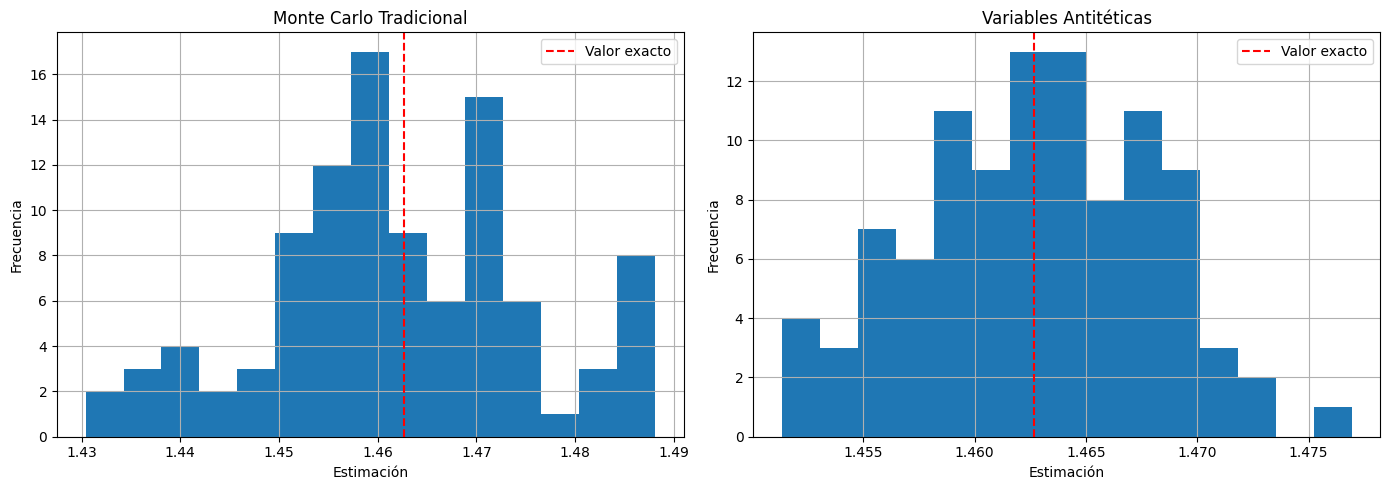

In [232]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Histograma Monte Carlo tradicional

ax[0].hist(resultados_mc, bins=15)

ax[0].axvline(
    valor_real,
    color='red',
    linestyle='--',
    label='Valor exacto'
)

ax[0].set_title("Monte Carlo Tradicional")
ax[0].set_xlabel("Estimación")
ax[0].set_ylabel("Frecuencia")
ax[0].legend()
ax[0].grid(True)

# Histograma Antitético

ax[1].hist(resultados_ant, bins=15)

ax[1].axvline(
    valor_real,
    color='red',
    linestyle='--',
    label='Valor exacto'
)

ax[1].set_title("Variables Antitéticas")
ax[1].set_xlabel("Estimación")
ax[1].set_ylabel("Frecuencia")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

## <span style="color:magenta;">**Conclusión** </span>
El estimador con variables antitéticas produce una varianza menor que el estimador Monte Carlo tradicional, debido a la correlación negativa entre $f(U)$ y $f(1-U)$. Como consecuencia, se obtienen intervalos de confianza más estrechos y una estimación más precisa sin incrementar el número de simulaciones.


## <span style="color:magenta;">**Conclusión General comparando ambos Métodos** </span>

* Ambos métodos producen estimaciones cercanas a (1.4626517459).
* El estimador antitético presenta una varianza menor.
* El error estándar disminuye.
* Los intervalos de confianza son más estrechos.

En conclusión, aunque ambos métodos convergen al valor verdadero de la integral, la técnica de variables antitéticas resulta más eficiente, ya que logra reducir la variabilidad del estimador y mejorar la calidad de las estimaciones manteniendo el mismo esfuerzo de simulación.